# Linear Regression — Insurance Charges
**Dataset:** Medical Cost Personal Dataset  
**Goal:** Predict individual medical insurance charges based on personal attributes  
**Kernel:** Python (mlvenv)

---

## Problem Statement

Insurance companies need to estimate medical costs for customers before setting premium prices. The goal of this project is to build a **linear regression model** that predicts individual medical charges billed by health insurance, based on a customer's personal attributes.

This mirrors real-world actuarial and pricing models used in the insurance industry.

---

## Dataset Description

- **Source:** [Medical Cost Personal Dataset](https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv)
- **Size:** 1,338 rows × 7 columns
- **Target:** `charges` — individual medical costs billed by insurance (continuous, USD)

| Feature | Type | Description |
|---|---|---|
| `age` | Numeric | Age of the primary beneficiary |
| `sex` | Categorical | Male / Female |
| `bmi` | Numeric | Body mass index |
| `children` | Numeric | Number of dependents covered |
| `smoker` | Categorical | Yes / No |
| `region` | Categorical | Northeast, Southeast, Southwest, Northwest |
| `charges` | **Target** | Medical costs billed by insurance |

---

## Project Plan

1. **Imports** — load all required libraries
2. **Load Data** — fetch dataset directly from URL
3. **Exploratory Data Analysis (EDA)** — understand distributions, correlations, and key patterns
4. **Preprocessing** — encode categorical variables, check for missing values, scale features
5. **Train / Test Split** — split data for unbiased evaluation
6. **Model Training** — fit a Linear Regression model using scikit-learn
7. **Evaluation** — assess model performance using R², RMSE, and MAE
8. **Residual Analysis** — verify linear regression assumptions
9. **Insights** — interpret coefficients and summarize findings

---

## 1. Imports & Data Load

In [1]:
import sys
print(sys.executable)

/Users/abhinavbanerjee/Desktop/AI/MachineLearning /mlvenv/bin/python3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline

## 2. Load Data

In [3]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape

(1338, 7)

In [6]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [7]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 3. Exploratory Data Analysis

### 3a. Summary Statistics

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


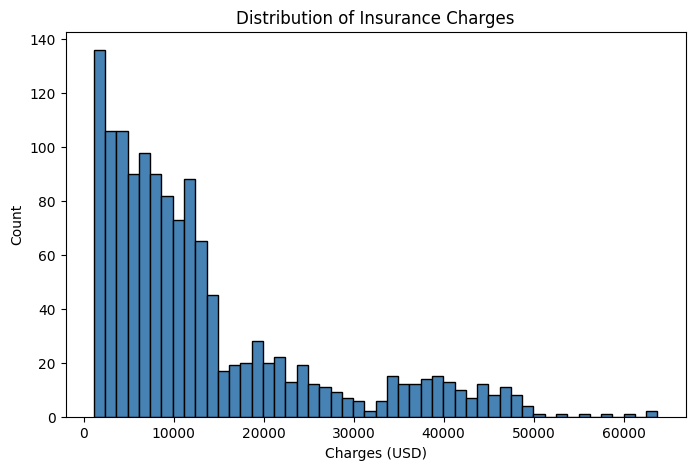

In [9]:
# Checking distribution of the target feature i.e. 'charges'

plt.figure(figsize=(8, 5))
plt.hist(df['charges'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.ylabel('Count')
plt.show()

### 3b. Target Distribution — Log Transformation

The histogram shows that `charges` is right-skewed i.e. the majority of people have charges between $1,000–$15,000, but a small group has charges stretching all the way to $63,000. This long tail is a problem for linear regression because:

- **a.** The model gets pulled toward the extreme high values
- **b.** The residuals (errors) won't be normally distributed, violating a core assumption of linear regression
- **c.** Predictions on low-charge patients will be less accurate

Taking `log(charges)` compresses that long tail and makes the distribution much more bell-shaped, which linear regression handles significantly better.

In short: the model works, but it's biased — it performs poorly on the majority of customers (low charges) because it's being pulled by the minority (high charges). Log transforming the target fixes this by putting all values on a more equal footing.

In [10]:
df['log_charges'] = np.log(df['charges'])
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


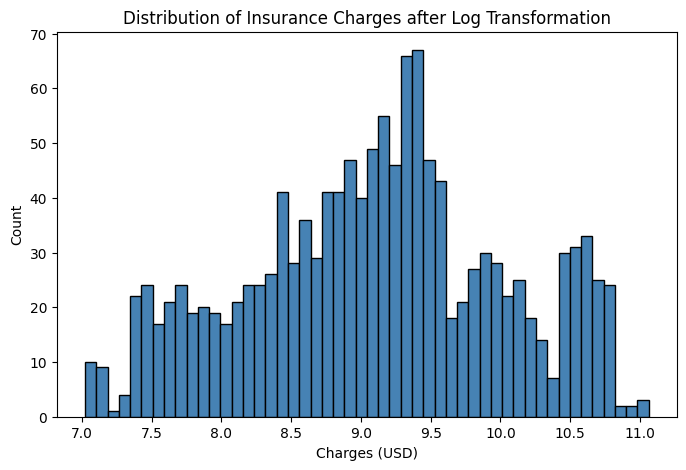

In [11]:
# Verifying the distribution of the column 'log_charges'

plt.figure(figsize=(8, 5))
plt.hist(df['log_charges'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Insurance Charges after Log Transformation')
plt.xlabel('Charges (USD)')
plt.ylabel('Count')
plt.show()

### 3c. Categorical Feature Counts

In [12]:
df[['sex', 'smoker', 'region']].head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


In [13]:
df['sex'].value_counts()

sex
male      676
female    662
Name: count, dtype: int64

In [14]:
df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [15]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

### 3d. Smoker vs Charges

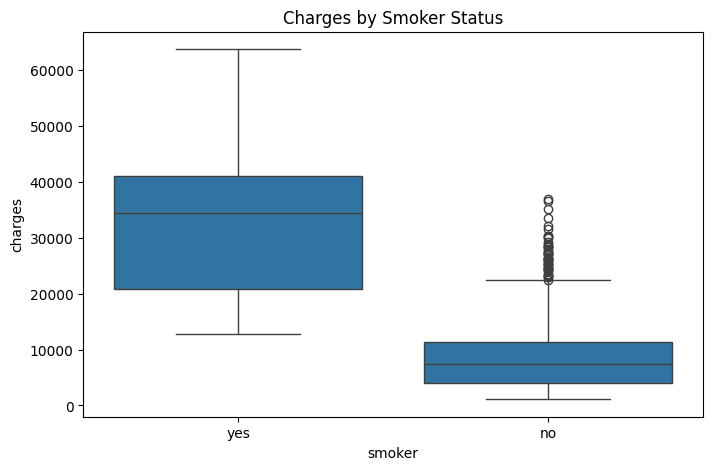

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker Status')
plt.show()

## 4. Data Preprocessing

In [23]:
df.head()

# Encode columns 'sex' and 'smoker' for now. For the first iteration, we will be dropping 'region'

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


In [21]:
from sklearn.preprocessing import LabelEncoder

In [24]:
le = LabelEncoder()
df['sex_preprocessed'] = le.fit_transform(df['sex'])

In [25]:
df['smoker_preprocessed'] = le.fit_transform(df['smoker'])

In [ ]:
df.head()

# Checking the pre-processed columns

,age,sex,bmi,children,smoker,region,charges,log_charges,sex_preprocessed,smoker_preprocessed
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176,0,1
1,18,male,33.770,1,no,southeast,1725.55230,7.453302,1,0
2,28,male,33.000,3,no,southeast,4449.46200,8.400538,1,0
3,33,male,22.705,0,no,northwest,21984.47061,9.998092,1,0
4,32,male,28.880,0,no,northwest,3866.85520,8.260197,1,0


## 5. Train/Test Split

### 5a. Define X and y

In [28]:
X = df[['age', 'sex_preprocessed', 'bmi', 'children', 'smoker_preprocessed']]
y = df['log_charges']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")

Training set size: (1070, 5)
Test set size:     (268, 5)


## 6. Feature Scaling

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Why we fit the scaler only on training data — No Data Leakage

**The golden rule:** anything that "learns" from data (scalers, encoders, the model itself) must only learn from **training data**. Test data is always transformed, never fitted.

---

#### What StandardScaler does

It rescales each feature using:
```
z = (x - mean) / std
```
This centers data around 0 and gives it a spread of roughly -2 to +2, regardless of original units.

---

#### Why NOT to fit the scaler on all data first

If you scale the whole dataset before splitting:

- The scaler learns the mean and std from **both training and test data**
- Test data secretly influences how training data is scaled
- Your model trains on a distribution that was "contaminated" by test data
- Evaluation metrics look better than they really are
- In production, this won't hold — new data won't have influenced the scaler

**Example:**
- Training ages: 20, 30, 40 → mean = 30
- Test ages: 50, 60
- If scaled together → mean = 40 (test data pulled it up)
- Training was scaled using a mean it should never have known about

---

#### The correct way

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # learns from training only
X_test_scaled  = scaler.transform(X_test)        # applies training stats to test
```

- `fit_transform` on training → learns mean/std, then scales
- `transform` on test → applies the **same** training statistics, no new learning

This keeps training, test, and future production data all consistent.

## 7. Model Training

### 7a. Instantiate and fit the model

In [31]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 7b. Inspect the model

In [32]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 9.113322337921884
Coefficients: [ 0.4826004  -0.03610885  0.06936199  0.11307286  0.62645377]


A positive coefficient means that feature increases `log_charges`. A negative one means it decreases it. The larger the absolute value, the stronger the effect.

### Interpreting the Coefficients

The model learned one coefficient per feature. Here's how to read them:

- **Positive coefficient** → as that feature increases, `log_charges` increases (higher charges)
- **Negative coefficient** → as that feature increases, `log_charges` decreases (lower charges)
- **Larger absolute value** → stronger effect on charges

---

#### Our encoding (important for interpretation)

| Feature | Encoding |
|---|---|
| `sex` | female = 0, male = 1 |
| `smoker` | no = 0, yes = 1 |

---

#### What the coefficients tell us

| Feature | Sign | Interpretation |
|---|---|---|
| `age` | Positive | Older → higher charges |
| `sex` | Negative | Male (1) → slightly lower charges than female (0) |
| `bmi` | Positive | Higher BMI → higher charges |
| `children` | Positive | More dependents → higher charges |
| `smoker` | Positive | Smoker (1) → much higher charges than non-smoker (0) |

The largest coefficient by far is `smoker` — consistent with what the boxplot showed during EDA.
This is why linear regression is valuable in insurance: you can explain exactly why a prediction is what it is.

### 7c. Make predictions

In [35]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

## 8. Evaluation

In [36]:
mse  = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

print(f"R²   : {r2:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")

R²   : 0.7983
RMSE : 0.4259
MAE  : 0.2755


### 8b. Understanding the Metrics — With Examples

All three metrics compare **actual vs predicted** values. The difference between them is *how* they summarise the errors.

---

#### The error for each prediction

```
error = actual log_charges − predicted log_charges
```

A small error = good prediction. A large error = bad prediction.

---

#### MAE — Mean Absolute Error
> "What is the typical error?"

- Take each error, make it positive (absolute value), then average them all
- Every prediction's error is weighted **equally** — a big miss counts the same as a small miss, just proportionally
- **MAE = 0.2755** → the typical prediction is off by 0.28 log units

---

#### RMSE — Root Mean Squared Error
> "Are there any really bad predictions?"

- Square each error before averaging, then square root at the end
- Squaring **amplifies large errors** — a miss of 0.7 contributes 49× more than a miss of 0.1
- So RMSE is pulled upward whenever there are a few badly wrong predictions
- **RMSE = 0.4259** → larger than MAE because a handful of predictions are badly off

**The key signal:** RMSE (0.43) is noticeably larger than MAE (0.28). If all errors were similar in size, they'd be close. The gap tells you the model is making a few large mistakes — most likely on the non-smokers with unexpectedly high charges seen in the EDA boxplot.

---

#### R² — R-squared
> "How much better is the model vs just guessing the mean every time?"

- Baseline: if you had no model, your best guess for everyone would be the **average charge**
- R² measures how much your model reduces error compared to that dumb baseline
- R² = 0 → no better than guessing the mean
- R² = 1 → perfect predictions
- **R² = 0.7983** → the model explains **80% of why charges vary** between people

The remaining 20% is unexplained — likely factors not in the dataset (pre-existing conditions, specific treatments, etc.)

---

#### One-line summary

| Metric | Value | Plain English |
|---|---|---|
| R² | 0.7983 | Model is 80% better than guessing the mean — solid result |
| MAE | 0.2755 | Typical prediction is off by 0.28 log units |
| RMSE | 0.4259 | A few predictions are badly wrong, pulling this above MAE |

## 9. Residual Analysis

### 9a. Residuals vs Predicted

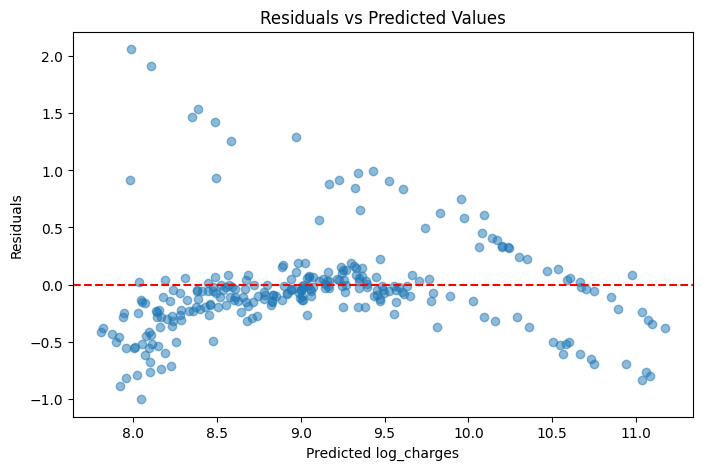

In [37]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted log_charges')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()

### 9b. Distribution of Residuals

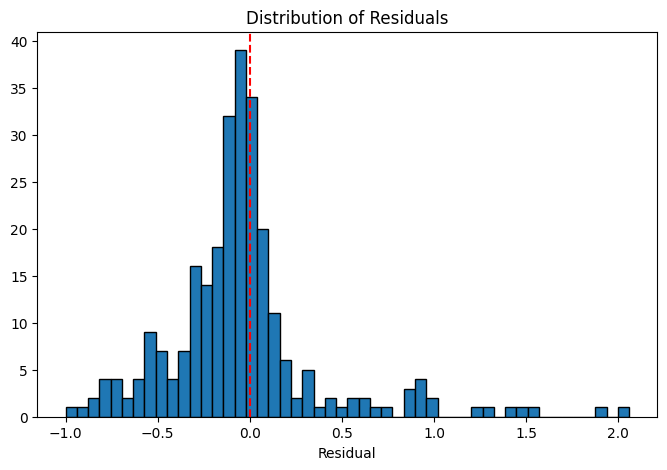

In [38]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.title('Distribution of Residuals')
plt.show()

### 9c. Why Does the Residual Plot Show a Curve?

The data has two distinct populations — non-smokers (low charges) and smokers (high charges). If you plotted age vs charges, you'd see two separate bands:

```
Charges
  |              * smokers
  |           *  *  *
  |        *     *
  |  * * * * * * * * *   ← non-smokers with high charges
  |* * * * * * * * *
  |* * * * * * * * *     ← most non-smokers
  +---------------------- Age
```

Linear regression draws **one straight line** through all of this. It can't draw two separate lines for smokers and non-smokers — it finds the single best compromise line that sits somewhere in the middle.

So:
- For **low predicted values** (non-smokers, low charges) → the line runs above them → actual is lower than predicted → **negative residuals**
- For **mid predicted values** → the line passes through → **residuals near zero**
- For **high predicted values** (smokers, high charges) → the line runs below them → actual is higher than predicted → **positive residuals**

When you plot that — negative on the left, zero in the middle, positive on the right — it looks like a curve.

**The curve is the model saying:** *"I'm one straight line trying to represent two separate populations. I'm systematically wrong at both ends because I can't split them apart."*
